In [1]:
import pandas as pd

# Load the datasets
expenditure_type_df = pd.read_csv('government-expenditure-by-type.csv')
fiscal_position_df = pd.read_csv('government-fiscal-position.csv')
manpower_df = pd.read_csv('government-manpower.csv')
operating_revenue_df = pd.read_csv('government-operating-revenue.csv')
total_expenditure_df = pd.read_csv('government-total-expenditure.csv')

# Display head and info of each to understand the data
print("Expenditure by Type:")
print(expenditure_type_df.head())
print(expenditure_type_df.info())

print("\nFiscal Position:")
print(fiscal_position_df.head())
print(fiscal_position_df.info())

print("\nManpower:")
print(manpower_df.head())
print(manpower_df.info())

print("\nOperating Revenue:")
print(operating_revenue_df.head())
print(operating_revenue_df.info())

print("\nTotal Expenditure:")
print(total_expenditure_df.head())
print(total_expenditure_df.info())

Expenditure by Type:
   financial_year actual_revised_estimated       type      category  \
0            1997                   Actual  Operating  Running Cost   
1            1998                   Actual  Operating  Running Cost   
2            1999                   Actual  Operating  Running Cost   
3            2000                   Actual  Operating  Running Cost   
4            2001                   Actual  Operating  Running Cost   

                     class  amount  
0  Expenditure on Manpower    3063  
1  Expenditure on Manpower    2896  
2  Expenditure on Manpower    2872  
3  Expenditure on Manpower    3276  
4  Expenditure on Manpower    3351  
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   financial_year            200 non-null    int64
 1   actual_revised_estimated  200 non-null    str  
 2   type                

   financial_year  total_expenditure  total_revenue  expenditure_growth  \
0            1997              23040          29181                 NaN   
1            1998              26934          27911           16.901042   
2            1999              25079          30647           -6.887206   
3            2000              27909          31439           11.284341   
4            2001              27306          28494           -2.160593   

   revenue_growth  
0             NaN  
1       -4.352147  
2        9.802587  
3        2.584266  
4       -9.367346  
                    total_expenditure  total_revenue  expenditure_growth  \
total_expenditure            1.000000       0.938217            0.329403   
total_revenue                0.938217       1.000000            0.215370   
expenditure_growth           0.329403       0.215370            1.000000   
revenue_growth               0.037745       0.167394           -0.095613   

                    revenue_growth  
total_expen

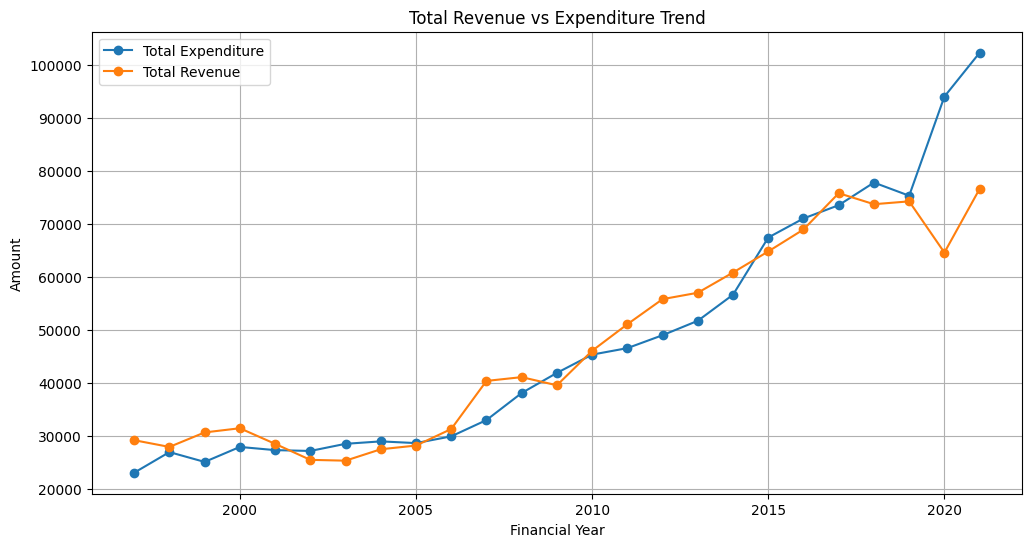

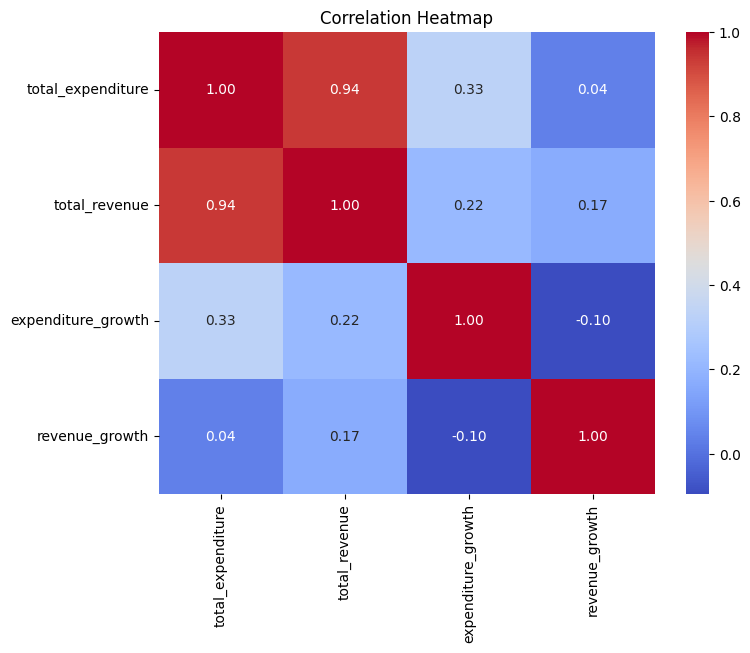

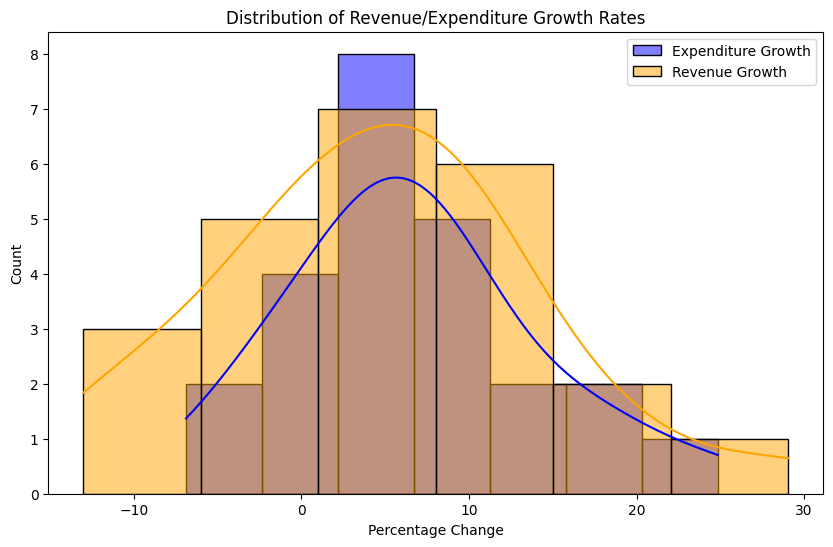

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aggregate expenditure by financial_year
expenditure_yearly = total_expenditure_df.groupby('financial_year')['amount'].sum().reset_index()
expenditure_yearly.rename(columns={'amount': 'total_expenditure'}, inplace=True)

# Aggregate revenue by financial_year
revenue_yearly = operating_revenue_df.groupby('financial_year')['amount'].sum().reset_index()
revenue_yearly.rename(columns={'amount': 'total_revenue'}, inplace=True)

# Merge datasets
combined_df = pd.merge(expenditure_yearly, revenue_yearly, on='financial_year', how='outer').fillna(0)

# Calculate "return" (year-over-year percentage change)
combined_df['expenditure_growth'] = combined_df['total_expenditure'].pct_change() * 100
combined_df['revenue_growth'] = combined_df['total_revenue'].pct_change() * 100

# Visualize trends
plt.figure(figsize=(12, 6))
plt.plot(combined_df['financial_year'], combined_df['total_expenditure'], label='Total Expenditure', marker='o')
plt.plot(combined_df['financial_year'], combined_df['total_revenue'], label='Total Revenue', marker='o')
plt.xlabel('Financial Year')
plt.ylabel('Amount')
plt.title('Total Revenue vs Expenditure Trend')
plt.legend()
plt.grid(True)
plt.savefig('revenue_expenditure_trend.png')

# Heatmap for correlation
plt.figure(figsize=(8, 6))
correlation_matrix = combined_df[['total_expenditure', 'total_revenue', 'expenditure_growth', 'revenue_growth']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# Distribution of growth rates (returns)
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['expenditure_growth'].dropna(), kde=True, color='blue', label='Expenditure Growth')
sns.histplot(combined_df['revenue_growth'].dropna(), kde=True, color='orange', label='Revenue Growth')
plt.xlabel('Percentage Change')
plt.title('Distribution of Revenue/Expenditure Growth Rates')
plt.legend()
plt.savefig('growth_distribution.png')

print(combined_df.head())
print(correlation_matrix)